# Visualizing results

In [86]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [87]:
experiment_dir = "/home/lnishimw/scratch/experiments/evaluation-challenges/llm/experiment_049d"

In [88]:
score_dir = f"{experiment_dir}/scores"
score_files = {
    corpus: f"{score_dir}/scores_{corpus}.csv" for corpus in ["rocsmt", "footweets", "mmtc", "pfsmb"] #, "rocsmt-gpt", "footweets-gpt", "mmtc-gpt", "pfsmb-gpt"]
}

In [89]:
dfs = {corpus: pd.read_csv(score_files[corpus]) for corpus in score_files}

In [90]:
from llm.prompt_templates import LLAMA_MODEL_NAME, GEMMA_MODEL_NAME, NLLB_MODEL_NAME, TOWER_MODEL_NAME, GUIDELINES

In [91]:
GEMMA ="google/gemma-2-9b-it"
LLAMA = "meta-llama/Llama-3.1-8B-Instruct"
TOWER = "Unbabel/TowerInstruct-7B-v0.2"
NLLB = "facebook/nllb-200-3.3B"

In [92]:
MODELS = {
    NLLB_MODEL_NAME:{
        "name": "NLLB-3B",
        "id": "0",
    },
    LLAMA_MODEL_NAME:{
        "name": "LLaMa-3.1-8B",
        "id": "1",
    },
    GEMMA_MODEL_NAME:{
        "name": "Gemma-2-9B",
        "id": "2",
    },
    TOWER_MODEL_NAME:{
        "name": "Tower-7B-v0.2",
        "id": "3",
    },
}

In [93]:
CORPORA = {
    "rocsmt": {
        "name": "RoCS-MT",
        "id": "0",
        "refs": "raw",
        "lang_pair": "En-Fr" 
    },
    "rocsmt-gpt": {
        "name": "RoCS-MT",
        "id": "1",
        "refs": "norm",
        "lang_pair": "En-Fr" 
    },
    "footweets": {
        "name": "FooTweets",
        "id": "2",
        "refs": "raw",
        "lang_pair": "En-De" 
    },
    "footweets-gpt": {
        "name": "FooTweets",
        "id": "3",
        "refs": "norm",
        "lang_pair": "En-De" 
    },
    "mmtc": {
        "name": "MMTC",
        "id": "4",
        "refs": "raw",
        "lang_pair": "Fr-En" 
    },
    "mmtc-gpt": {
        "name": "MMTC",
        "id": "5",
        "refs": "norm",
        "lang_pair": "Fr-En" 
    },
    "pfsmb": {
        "name": "PFSMB",
        "id": "6",
        "refs": "raw",
        "lang_pair": "Fr-En" 
    },
    "pfsmb-gpt": {
        "name": "PFSMB",
        "id": "7",
        "refs": "norm",
        "lang_pair": "Fr-En" 
    }
}

In [94]:
def get_guideline_display(guideline):
    if guideline == "default":
        return ""
    if guideline in CORPORA:
        guideline = CORPORA[guideline]["name"]
    return f" + {guideline}"

GUIDELINE_NAMES_IDS = {
    "default": 0,
    get_guideline_display("standard"): 1,
    get_guideline_display("general"): 2,
    get_guideline_display("rocsmt"): 3,
    get_guideline_display("footweets"): 4,
    get_guideline_display("mmtc"): 5,
    get_guideline_display("pfsmb"): 6,
}

In [95]:
LANG_PAIRS = {
    "RoCS-MT": "En-Fr",
    "FooTweets": "En-De",
    "MMTC": "Fr-En",
    "PFSMB": "Fr-En"
}

In [96]:
def get_guidelines(filename):
    guideline = filename.split(".")[-3] # guidelines.out.postproc
    if guideline not in GUIDELINES:
        guideline = "default"
    return get_guideline_display(guideline)

def get_model_name(model):
    return MODELS[model.split("/")[-1]]["name"]

def get_model_id(model):
    return MODELS[model.split("/")[-1]]["id"]

def get_guideline_id(guideline):
    if not guideline:
        return GUIDELINE_NAMES_IDS["default"]
    return GUIDELINE_NAMES_IDS[guideline]

def get_corpus_id(corpus):
    return CORPORA[corpus]["id"]

def get_corpus_name(corpus):
    return CORPORA[corpus]["name"]

def get_reference_type(corpus):
    return CORPORA[corpus]["refs"]

def get_lang_pair(corpus_name):
    return LANG_PAIRS[corpus_name]

In [97]:
def normalize_error_counts(data):
    for severity in ["minor", "major", "critical", "total"]:
        data[severity] = data[severity] / data["total_sents"] * 100
    return data

def normalize_error_counts_sents(data):
    for severity in ["minor", "major", "critical", "correct"]:
        data[f"{severity}_sents"] = data[f"{severity}_sents"] / data["total_sents"] * 100
    return data

In [98]:
def get_lines(corpus):
    if "rocsmt" in corpus:
        return 1922
    if "footweets" in corpus:
        return 4000
    if "mmtc" in corpus:
        return 2000
    if "pfsmb" in corpus:
        return 777

In [99]:
all_data = pd.DataFrame()

for corpus in dfs:
    data = dfs[corpus].copy()
    data["guideline"] = data["file"].apply(get_guidelines)
    data["model_name"] = data["model"].apply(get_model_name) + data["guideline"] 
    data["model_id"] = data["model"].apply(get_model_id)
    data["guideline_id"] = data["guideline"].apply(get_guideline_id)
    data["corpus"] = get_corpus_name(corpus)
    data["corpus_id"] = get_corpus_id(corpus)
    # data["reference_type"] = get_reference_type(corpus)
    data["total_sents"] = get_lines(corpus)
    all_data = all_data.append(data)


In [100]:
# all_data = all_data.sort_values(["corpus_id", "model_id", "guideline_id", "reference_type"], ascending=[True, True, True, False])
all_data = all_data.sort_values(["corpus_id", "model_id", "guideline_id"], ascending=[True, True, True])
all_data.head()

,model,file,bleu,chrf2,comet,cometkiwi,guideline,model_name,model_id,guideline_id,corpus,corpus_id,total_sents
0,facebook/nllb-200-3.3B,raw.en.test.out.postproc,21.332086,43.825091,73.213880,75.520964,,NLLB-3B,0,0,RoCS-MT,0,1922
5,meta-llama/Llama-3.1-8B-Instruct,raw.en.test.default.out.postproc,20.043699,42.551980,73.503729,75.433357,,LLaMa-3.1-8B,1,0,RoCS-MT,0,1922
4,meta-llama/Llama-3.1-8B-Instruct,raw.en.test.rocsmt.out.postproc,19.875813,41.972477,71.900823,73.515542,+ RoCS-MT,LLaMa-3.1-8B + RoCS-MT,1,3,RoCS-MT,0,1922
3,meta-llama/Llama-3.1-8B-Instruct,raw.en.test.footweets.out.postproc,19.350917,41.378012,71.268964,73.091801,+ FooTweets,LLaMa-3.1-8B + FooTweets,1,4,RoCS-MT,0,1922
1,meta-llama/Llama-3.1-8B-Instruct,raw.en.test.mmtc.out.postproc,19.138653,41.177186,70.935968,72.596942,+ MMTC,LLaMa-3.1-8B + MMTC,1,5,RoCS-MT,0,1922


## True references (raw) vs. GPT4-normalized references (norm)

In [60]:
def plot_scores_by_ref(all_data, metrics, sharex=True, sharey=True):
    corpora = all_data["corpus"].unique()
    fig, axs = plt.subplots(len(corpora), len(metrics), figsize=(4*len(metrics), 3*len(corpora)), sharex=sharex, sharey=sharey)
    for i, corpus in enumerate(corpora):
        for j, metric in enumerate(metrics):
            data = all_data[all_data["corpus"] == corpus]
            sns.barplot(x=metric, y="model_name", hue="reference_type", ax=axs[i,j], data=data) #, vmin=0, vmax=100) , cmap="YlGnBu"
            axs[i,j].set_title(f"{corpus} ({get_lang_pair(corpus)})")
            axs[i,j].set_ylabel("Model (+ Guidelines)")
    plt.tight_layout()
    plt.show()


ValueError: Could not interpret input 'reference_type'

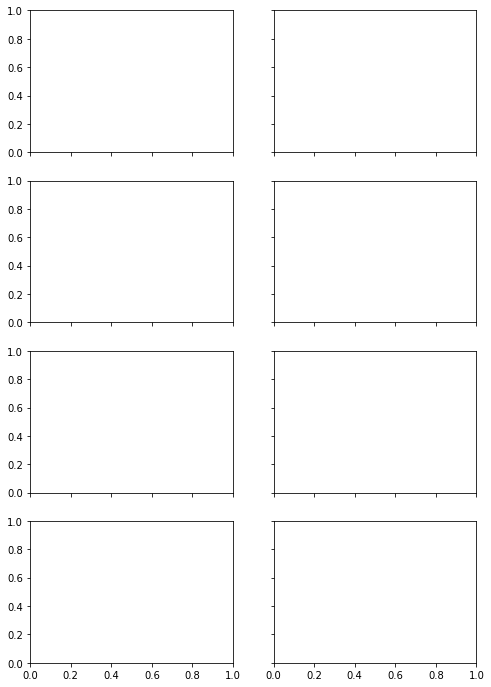

In [61]:
metrics = ["comet", "bleu"]
plot_scores_by_ref(all_data, metrics)

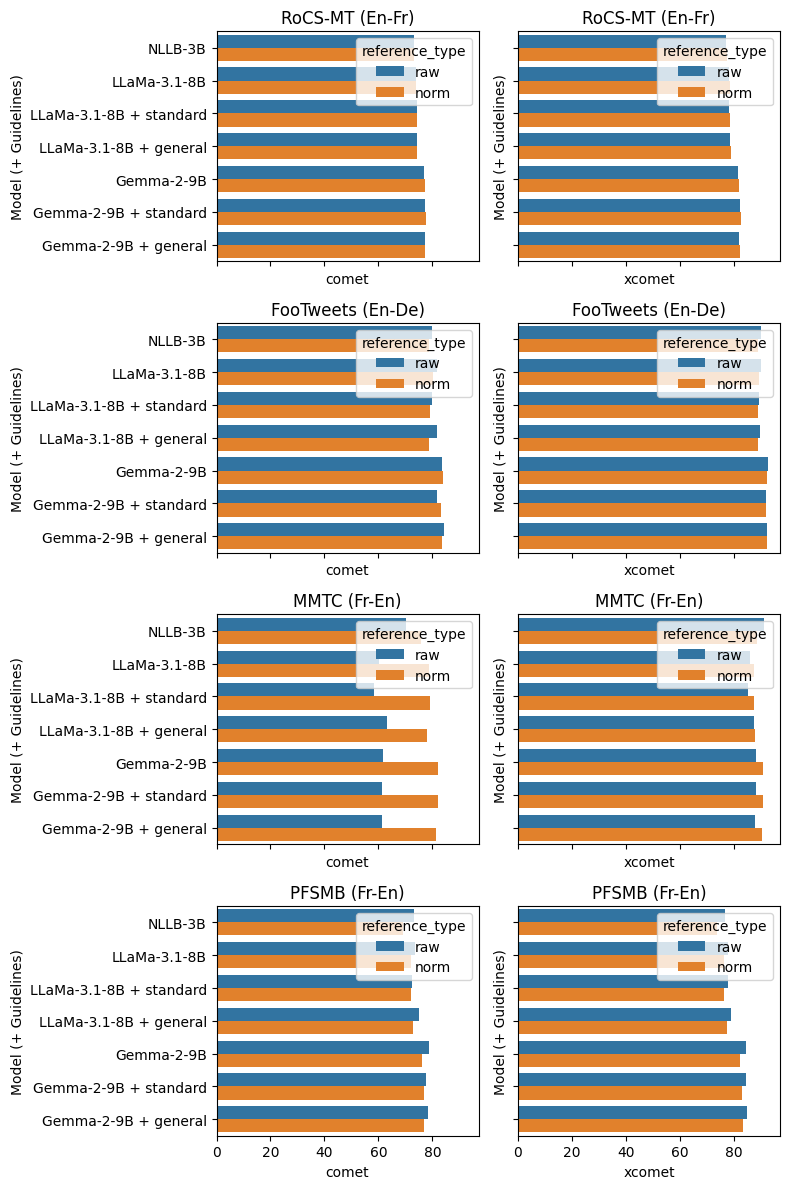

In [ ]:
metrics = ["comet", "xcomet"]
plot_scores_by_ref(all_data, metrics)

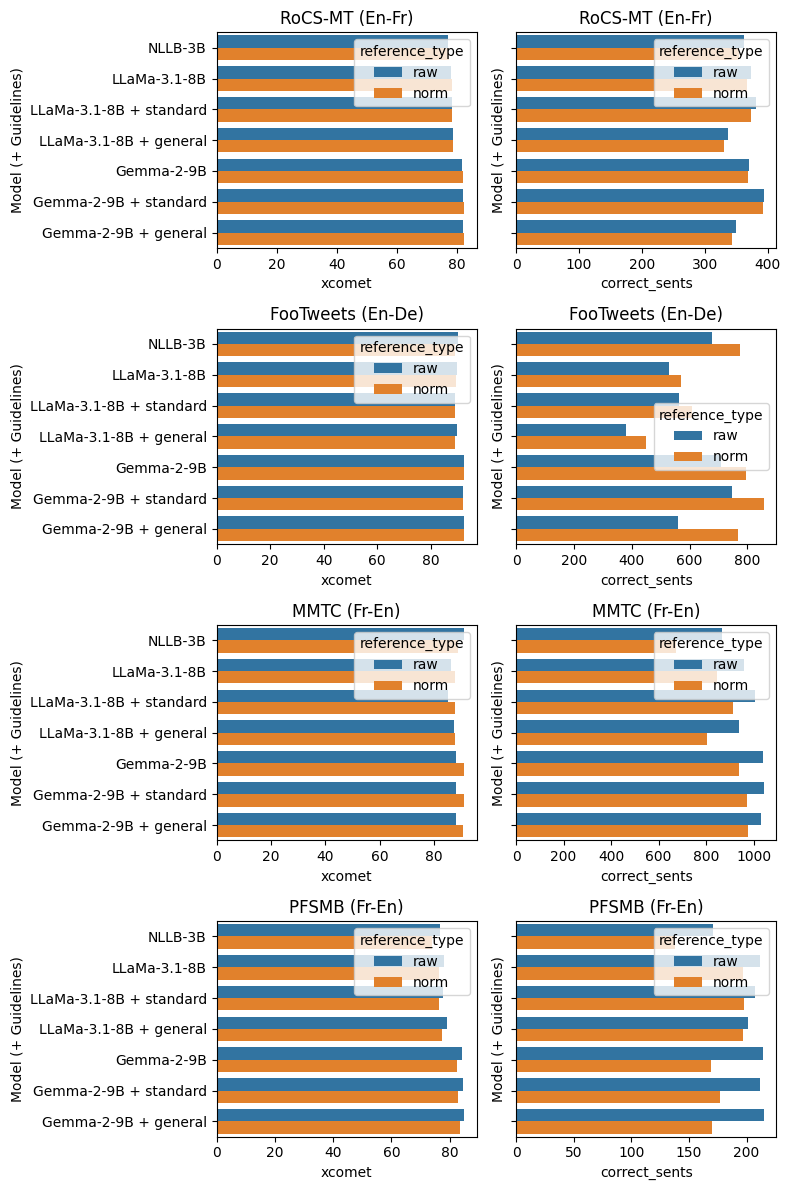

In [ ]:
metrics = ["xcomet", "correct_sents"]
plot_scores_by_ref(all_data, metrics, sharex=False)

KeyError: "['minor_sents', 'major_sents', 'critical_sents', 'correct_sents'] not in index"

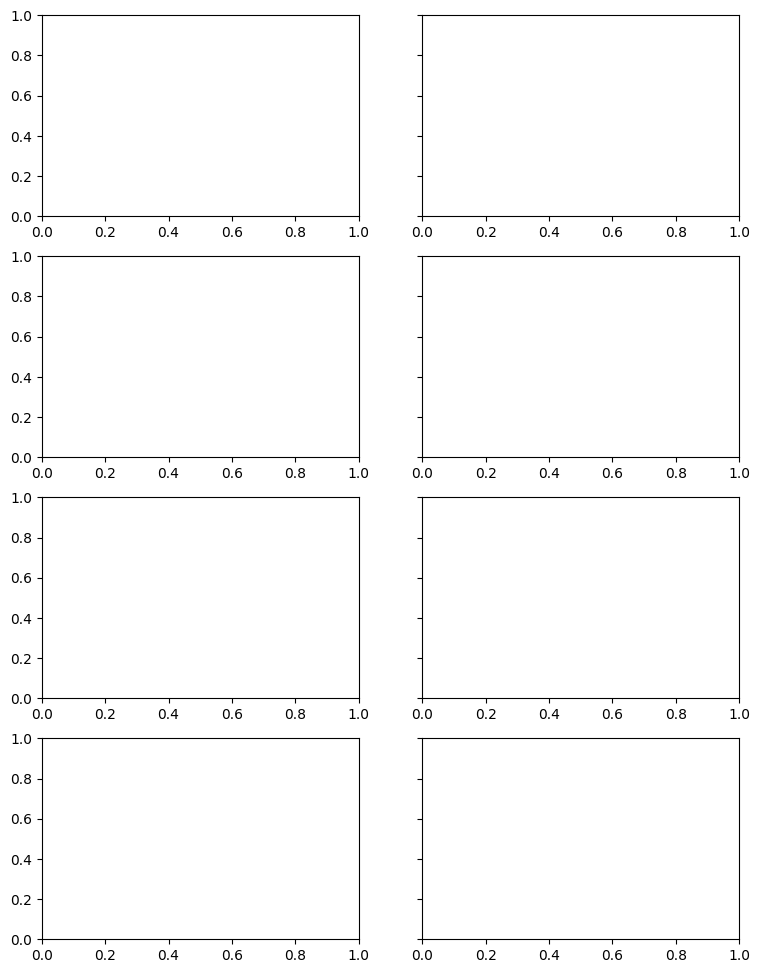

In [ ]:
ERROR_SEVERITY_TYPES = ["Minor", "Major", "Critical", "None"]

def plot_error_types_by_ref(all_data):
    reference_types = all_data["reference_type"].unique()
    corpora = all_data["corpus"].unique()
    fig, axs = plt.subplots(len(corpora), len(reference_types), figsize=(4*len(reference_types)+1, 3*len(corpora)), sharey=True, sharex=False)
    for i, corpus in enumerate(corpora):
        for j, ref in enumerate(reference_types):
            data = all_data[(all_data["corpus"] == corpus) & (all_data["reference_type"] == ref)]
            data = data[["model_name", "minor_sents", "major_sents", "critical_sents", "correct_sents"]]
            sns.heatmap(data.set_index("model_name"), annot=True, fmt=".0f", cmap="YlGnBu", ax=axs[i,j]) #, vmin=0, vmax=100)
            axs[i,j].set_title(f"{corpus} ({ref} references)")
            axs[i,j].set_xticklabels(ERROR_SEVERITY_TYPES, rotation=0)
            axs[i,j].set_yticklabels(data["model_name"].unique(), rotation=0)
            # reduce annotations font size
            for t in axs[i,j].texts:
                t.set_fontsize(10)
    
    # Remove individual x-axis labels
    for ax in axs.flat:
        ax.set_xlabel('')
        ax.set_ylabel('')
    
    # Remove individual y-axis labels (except for the leftmost ones)
    for ax in axs[:,1:].flat:
        ax.set_ylabel('')
    
    fig.supylabel("Model (+ Guidelines)")
    fig.supxlabel("Error Severity")
    plt.tight_layout()
    plt.show()

plot_error_types_by_ref(all_data)

## Main plots

In [101]:
# main_data = all_data[
#     (all_data["reference_type"] == "raw") & 
#     (~all_data["guideline"].str.contains("standard|general"))
# ]
main_data = all_data.copy()

In [102]:
plot_dir = f"{experiment_dir}/plots"
os.makedirs(plot_dir, exist_ok=True)

### Metric heatmaps

In [18]:
# plot a heatmap with the y-axis as the model and the x-axis as the corpus and the annotations as the xcomet scores
def plot_metric_heatmap(all_data, output_dir, metric="comet", model_names=[NLLB_MODEL_NAME, LLAMA_MODEL_NAME, GEMMA_MODEL_NAME, TOWER_MODEL_NAME]):
    data = all_data[all_data["model"].str.contains("|".join(model_names))]
    corpora = data["corpus"].unique()
    models = data["model_name"].unique()
    fig, ax = plt.subplots(1, 1, figsize=(8,5))
    data = data.pivot(index="model_name", columns="corpus", values=metric)
    for column in data.columns:
        data.rename(columns={column: f"{column}\n({LANG_PAIRS[column]})"}, inplace=True)
    sns.heatmap(data, annot=True, fmt=".2f", cmap="YlGnBu", ax=ax)
    # ax.set_xlabel('')
    # ax.set_ylabel('')
    ax.set_ylabel("Model (+ Guidelines)", fontsize=16)
    ax.set_xlabel("Corpus", fontsize=16)
    # increase the font size of the annotations and the labels
    for t in ax.texts:
        t.set_fontsize(14)
    # increase the font size of the y-axis labels
    for t in ax.yaxis.get_ticklabels():
        t.set_fontsize(14)
    # increase the font size of the x-axis labels
    for t in ax.xaxis.get_ticklabels():
        t.set_fontsize(14)
    # increase the font size of the colorbar labels
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=14)
    plt.tight_layout()
    plt.savefig(f"{output_dir}/{metric}_heatmap_{'_'.join(model_names)}.pdf", format="pdf")



In [120]:
metric = "comet"

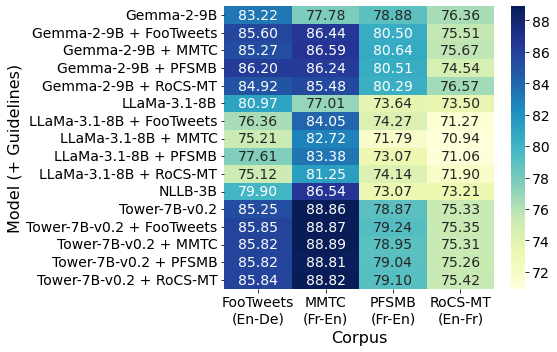

In [121]:
plot_metric_heatmap(main_data, plot_dir, metric, [NLLB_MODEL_NAME, LLAMA_MODEL_NAME, GEMMA_MODEL_NAME, TOWER_MODEL_NAME])

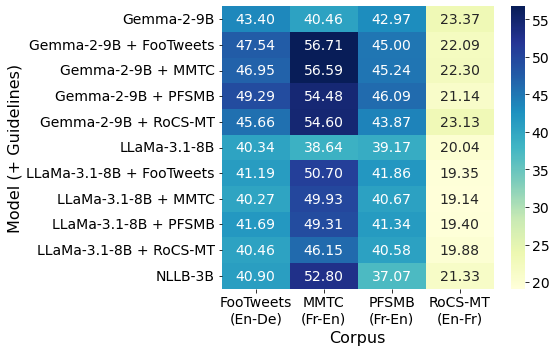

In [119]:
plot_metric_heatmap(main_data, plot_dir, metric, [NLLB_MODEL_NAME, LLAMA_MODEL_NAME, GEMMA_MODEL_NAME])

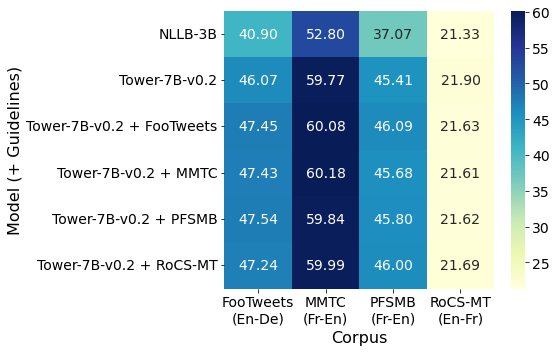

In [118]:
plot_metric_heatmap(main_data, plot_dir, metric, [NLLB_MODEL_NAME, TOWER_MODEL_NAME])

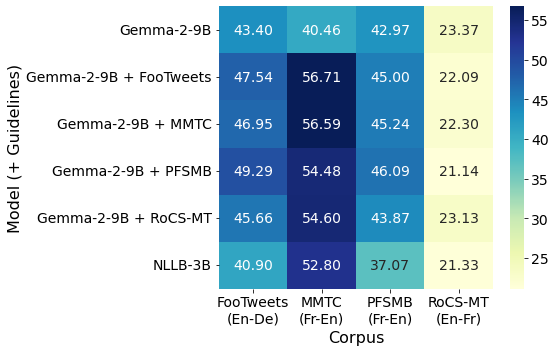

In [117]:
plot_metric_heatmap(main_data, plot_dir, metric, [NLLB_MODEL_NAME, GEMMA_MODEL_NAME])

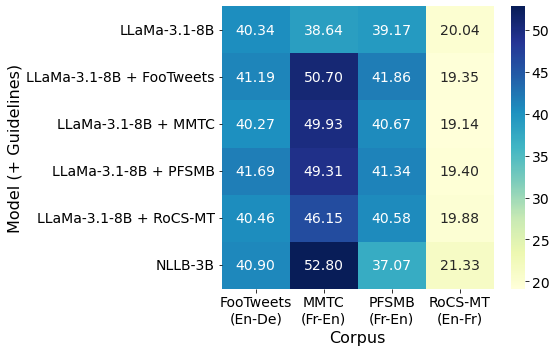

In [116]:
plot_metric_heatmap(main_data, plot_dir, metric, [NLLB_MODEL_NAME, LLAMA_MODEL_NAME])

# Analyzing error types

### Error types heatmaps

In [84]:
ERROR_COLUMNS = ["model_name", "minor", "major", "critical", "total"]
ERROR_SENTS_COLUMNS = ["model_name", "minor_sents", "major_sents", "critical_sents", "correct_sents"]

def plot_error_types(all_data, output_dir, sentence_counts=False): 
    corpora = all_data["corpus"].unique()
    n_cols = 2
    n_rows = math.ceil(len(corpora) / n_cols)
    fig, axs = plt.subplots(n_rows, n_cols, figsize=(4*n_cols+1, 3*n_rows+1), sharey=True, sharex=False)
    for k, corpus in enumerate(corpora):
        i, j = divmod(k, n_cols)
        data = all_data[all_data["corpus"] == corpus]
        columns = ERROR_SENTS_COLUMNS if sentence_counts else ERROR_COLUMNS
        data = data[columns]
        sns.heatmap(data.set_index("model_name"), annot=True, fmt=".0f", cmap="YlGnBu", ax=axs[i,j], vmin=0, vmax=250)
        axs[i,j].set_title(f"{corpus} ({get_lang_pair(corpus)})")
        xlabels = ERROR_SEVERITY_TYPES[:3] + ["Total"] if not sentence_counts else ERROR_SEVERITY_TYPES
        axs[i,j].set_xticklabels(xlabels, rotation=0)
        # reduce annotations font size
        for t in axs[i,j].texts:
            t.set_fontsize(10)
    
    # Remove individual x-axis labels
    for ax in axs.flat:
        ax.set_xlabel('')
        ax.set_ylabel('')
    
    # Remove individual y-axis labels (except for the leftmost ones)
    for ax in axs[:,1:].flat:
        ax.set_ylabel('')
    
    fig.supylabel("Model (+ Guidelines)")
    fig.supxlabel("Detected Error Severity (xCOMET-XL)")
    plt.tight_layout()
    # save plot to output dir
    filename = "error_types_sents_heatmap.pdf" if sentence_counts else "error_types_heatmap.pdf"
    plt.savefig(f"{output_dir}/{filename}", format="pdf")


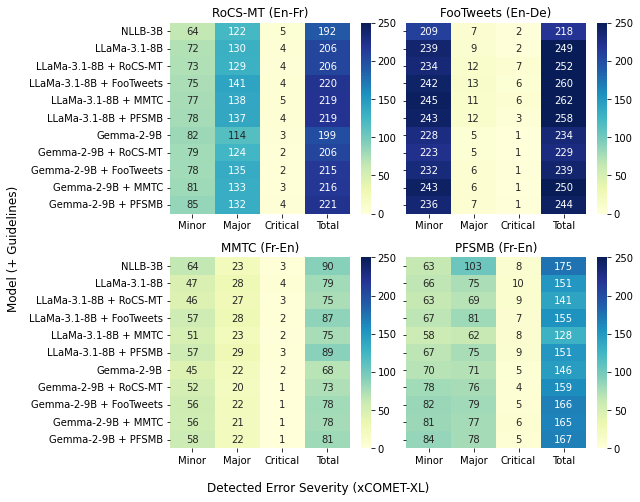

In [85]:

raw_data = all_data[
    (all_data["reference_type"] == "raw") & 
    (~all_data["guideline"].str.contains("standard|general"))
]
raw_data_norm_sent_counts = normalize_error_counts(main_data.copy())
plot_error_types(raw_data_norm_sent_counts, output_dir)
# plot_error_types_sents(main_data, output_dir)


In [59]:
raw_data_norm_sent_counts.head()

,model,file,bleu,chrf2,comet,xcomet,minor,major,critical,total,...,critical_sents,correct_sents,total_sents,guideline,model_name,model_id,guideline_id,corpus,corpus_id,reference_type
0,facebook/nllb-200-3.3B,raw.en.test.out,21.332086,43.825091,73.213880,77.169062,33.360456,63.791701,2.847844,3687,...,84,363,1922,,NLLB-3B,0,0,RoCS-MT,0,raw
1,meta-llama/Llama-3.1-8B-Instruct,raw.en.test.default.out,20.161005,42.723988,74.026405,78.217072,34.892541,63.185841,1.921618,3955,...,55,374,1922,,LLaMa-3.1-8B,1,0,RoCS-MT,0,raw
6,meta-llama/Llama-3.1-8B-Instruct,raw.en.test.rocsmt.out,19.736318,42.183723,74.475568,78.458084,35.228709,62.875916,1.895375,3957,...,55,363,1922,+ RoCS-MT,LLaMa-3.1-8B + RoCS-MT,1,3,RoCS-MT,0,raw
3,meta-llama/Llama-3.1-8B-Instruct,raw.en.test.footweets.out,19.071728,41.688063,73.660879,77.122374,34.185606,63.991477,1.822917,4224,...,60,314,1922,+ FooTweets,LLaMa-3.1-8B + FooTweets,1,4,RoCS-MT,0,raw
7,meta-llama/Llama-3.1-8B-Instruct,raw.en.test.mmtc.out,18.920558,41.387379,73.551141,77.009970,35.042735,62.844255,2.113010,4212,...,68,301,1922,+ MMTC,LLaMa-3.1-8B + MMTC,1,5,RoCS-MT,0,raw


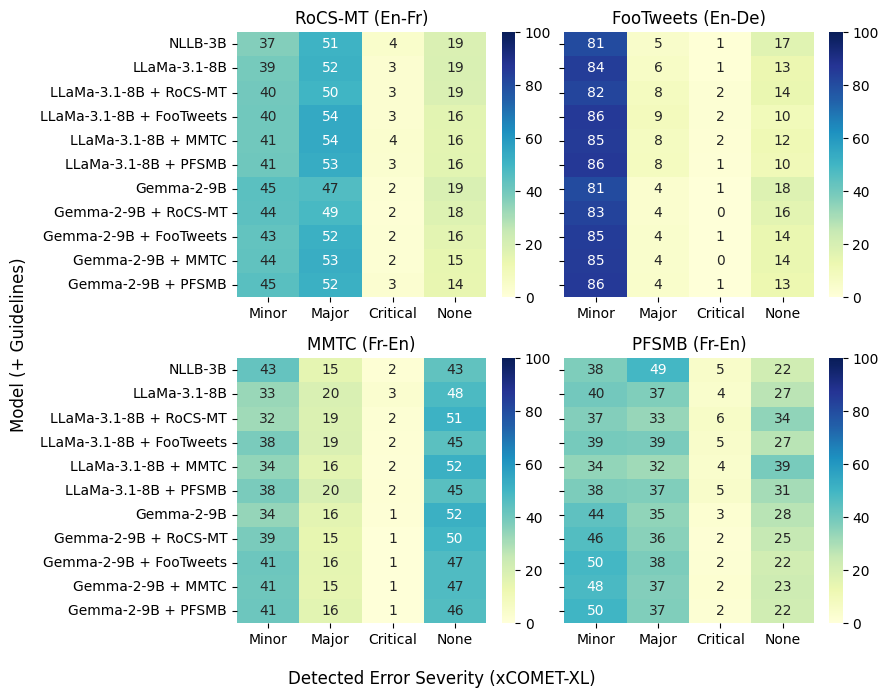

In [93]:
main_data_norm_sent_counts = normalize_error_counts_sents(main_data.copy())
# plot_error_types(raw_data_norm_sent_counts)
plot_error_types_sents(main_data_norm_sent_counts, output_dir)

In [19]:
import json

In [20]:
def get_errors(errors, severity):
    sentence_ids = []
    for i, sentence in enumerate(errors):
        for span in sentence["spans"]:
            if span["severity"] == severity:
                sentence_ids.append(i)
                break
    return set(sentence_ids)

def get_correct(errors):
    sentence_ids = []
    for i, sentence in enumerate(errors):
        if len(sentence["spans"]) == 0:
            sentence_ids.append(i)
    return set(sentence_ids)

In [21]:
src_file = "/home/lnishimw/scratch/datasets/mmtc/test.fr-en.fr"
ref_file = "/home/lnishimw/scratch/datasets/mmtc/test.fr-en.en"
ref_file_norm = "/home/lnishimw/scratch/datasets/mmtc/gpt.test.fr-en.en"

def read_file(file):
    with open(file, "r") as f:
        #get lines without newline character
        return [line.strip() for line in f.readlines()]

src = read_file(src_file)
ref = read_file(ref_file)
ref_norm = read_file(ref_file_norm)


In [22]:
model = "google/gemma-2-9b-it"
guideline = "default."
sys_file = f"/home/lnishimw/scratch/experiments/evaluation-challenges/experiment_049/outputs/{model}/mmtc/test.fr-en.fr.{guideline}out"
error_file = f"/home/lnishimw/scratch/experiments/evaluation-challenges/experiment_049/outputs/{model}/mmtc/test.fr-en.fr.{guideline}out.errors.json"
error_file_norm = f"/home/lnishimw/scratch/experiments/evaluation-challenges/experiment_049/outputs/{model}/mmtc-gpt/test.fr-en.fr.{guideline}out.errors.json"

with open(error_file, "r") as f:
    errors = json.load(f)

with open(error_file_norm, "r") as f:
    errors_norm = json.load(f)

sys = read_file(sys_file)

In [23]:
critical_errors = get_errors(errors, "critical")
critical_errors_norm = get_errors(errors_norm, "critical")

major_errors = get_errors(errors, "major")
major_errors_norm = get_errors(errors_norm, "major")

minor_errors = get_errors(errors, "minor")
minor_errors_norm = get_errors(errors_norm, "minor")

In [24]:
all_errors = critical_errors.union(major_errors).union(minor_errors)
all_errors_norm = critical_errors_norm.union(major_errors_norm).union(minor_errors_norm)

In [25]:
no_errors = get_correct(errors)
no_errors_norm = get_correct(errors_norm)

In [26]:
print("raw", "gpt")
print(len(critical_errors), len(critical_errors_norm))
print(len(major_errors), len(major_errors_norm))
print(len(minor_errors), len(minor_errors_norm))
print(len(all_errors), len(all_errors_norm))
print(len(no_errors), len(no_errors_norm))


raw gpt
29 23
316 365
675 749
960 1063
1040 937


In [27]:
# get intersection of critical errors
intersection = critical_errors.intersection(all_errors)
print(len(intersection))

29


In [28]:
for i in critical_errors:
    print("Line", (i+1))
    print("SRC:", src[i])
    print("SYS:", sys[i])
    print("REF (raw):", ref[i])
    print("ERRORS (raw):", errors[i])
    print("REF (gpt):", ref_norm[i])
    print("ERRORS (gpt):", errors_norm[i])
    print()

Line 387
SRC: @Ludo_Perverie Déjà fait l'an dernier
SYS: Already did it last year.
REF (raw): @Ludo_Perverie Already done last year
ERRORS (raw): {'score': 0.6809611320495605, 'spans': [{'text': 'Already did', 'confidence': 0.38789039850234985, 'severity': 'critical', 'start': 0, 'end': 11}]}
REF (gpt): @Ludo_Perverie Already done last year.
ERRORS (gpt): {'score': 0.9078869223594666, 'spans': [{'text': 'did', 'confidence': 0.3566102385520935, 'severity': 'minor', 'start': 7, 'end': 11}]}

Line 1667
SRC: RT @abracadaspliff: qui s'absente, ce fait oublier et aussitôt remplacé
SYS: Out of sight, out of mind and quickly replaced.
REF (raw): RT @abracadaspliff: he who is away, is forgotten and immediately replaced
ERRORS (raw): {'score': 0.4102344214916229, 'spans': [{'text': 'Out of sight, out of mind', 'confidence': 0.6553688049316406, 'severity': 'critical', 'start': 0, 'end': 25}]}
REF (gpt): He who is away is forgotten and immediately replaced.
ERRORS (gpt): {'score': 0.60814630985260

# Qualitative Analysis

## Selected examples

In [1]:
import json, yaml, os

In [2]:
corpus = "rocsmt"
rocsmt_line_numbers = [9,11,18,36,43,51,56,80,91,97,102,120,153,160,164,180,220,248,264,283,319,347,369,416,478,536,574,593,624,633,655,666,750,780,805,807,817,838,904,906,907,922,930,951,976,980,996,1015,1034,1047,1134,1153,1193,1205,1207,1230,1275,1311,1436,1462,1468,1482,1537,1548,1593,1596,1643,1648,1665,1739,1768,1780,1803,1922]
rocsmt_lines_ids = [k - 1 for k in rocsmt_line_numbers]

In [3]:
corpus = "footweets"
footweets_line_numbers = [2,3,7,18,21,22,24,26,30,35,177,195,337,374,414,422,525,536,573,610,637,707,718,914,1011,1093,1097,1350,1566,1567,1568,1569,1571,1612,1817,1992,2148,2420,2444,2525,2526,2544,2548,2590,2669,2670,2692,2813,2853,2885,2953,3354,3490,3566,3799,3910,3933,3986]
footweets_lines_ids = [k - 1 for k in footweets_line_numbers]

In [4]:
corpus = "mmtc"
mmtc_line_numbers = [1, 6, 8, 82, 96, 131, 188, 289, 301, 332, 441, 457, 610, 621, 667, 792, 801, 891, 976, 1008, 1035, 1179, 1262, 1465, 1522, 1627, 1643, 1667, 1712, 1746, 1763, 1774, 1782, 1862, 1898, 1935, 1963, 1999] 
mmtc_lines_ids = [k - 1 for k in mmtc_line_numbers]

In [5]:
corpus = "pfsmb"
pfsmb_line_numbers = [3,27,32,34,35,45,46,63,78,105,117,119,122,129,152,166,173,186,204,298,303,306,421,427,438,467,471,503,523,640,656,657,669,687,688,731,744,770]
pfsmb_lines_ids = [k - 1 for k in pfsmb_line_numbers]

In [6]:
corpora_config_file = "/home/lnishimw/evaluation-challenges/src/llm/config/corpora.yaml"
with open(corpora_config_file, "r") as f:
    corpora_config = yaml.safe_load(f)

In [35]:
corpora_config

{'rocsmt': {'src_file_path': '$DATASETS/rocsmt/test/raw.en.test',
  'ref_file_path': '$DATASETS/rocsmt/test/ref.fr.test'},
 'footweets': {'src_file_path': '$DATASETS/footweets/detok.twitter.sent.en.txt',
  'ref_file_path': '$DATASETS/footweets/detok.twitter.sent.de.txt'},
 'mmtc': {'src_file_path': '$DATASETS/mmtc/test.fr-en.fr',
  'ref_file_path': '$DATASETS/mmtc/test.fr-en.en'},
 'pfsmb': {'src_file_path': '$DATASETS/pfsmb/test.fr',
  'ref_file_path': '$DATASETS/pfsmb/test.en'},
 'rocsmt-gpt': {'src_file_path': '$DATASETS/rocsmt/test/raw.en.test',
  'ref_file_path': '$DATASETS/rocsmt/test/gpt.ref.fr.test'},
 'footweets-gpt': {'src_file_path': '$DATASETS/footweets/detok.twitter.sent.en.txt',
  'ref_file_path': '$DATASETS/footweets/gpt.detok.twitter.sent.de.txt'},
 'mmtc-gpt': {'src_file_path': '$DATASETS/mmtc/test.fr-en.fr',
  'ref_file_path': '$DATASETS/mmtc/gpt.test.fr-en.en'},
 'pfsmb-gpt': {'src_file_path': '$DATASETS/pfsmb/test.fr',
  'ref_file_path': '$DATASETS/pfsmb/gpt.test.en

In [7]:
analysis_lines = {
    "rocsmt": rocsmt_lines_ids,
    "footweets": footweets_lines_ids,
    "mmtc": mmtc_lines_ids,
    "pfsmb": pfsmb_lines_ids,
}

In [43]:
def read_file(file):
    with open(file, "r") as f:
        #get lines without newline character
        return [line.strip() for line in f.readlines()]

def read_json(file):
    with open(file, "r") as f:
        return json.load(f)
    
def write_json(file, data):
    with open(file, "w") as f:
        json.dump(data, f, indent=4)


In [30]:
from comet import download_model, load_from_checkpoint
from sacrebleu.metrics import BLEU
bleu_metric = BLEU(effective_order=True)
comet_model_path = download_model("Unbabel/wmt22-comet-da")
comet_model = load_from_checkpoint(comet_model_path)


/scratch/lnishimw/miniconda3/envs/sonar_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Fetching 5 files: 100%|██████████| 5/5 [00:00<00:00, 28807.03it/s]
Lightning automatically upgraded your loaded checkpoint from v1.8.3.post1 to v2.5.1. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ../../.cache/huggingface/hub/models--Unbabel--wmt22-comet-da/snapshots/2760a223ac957f30acfb18c8aa649b01cf1d75f2/checkpoints/model.ckpt`
/scratch/lnishimw/miniconda3/envs/sonar_env/lib/python3.10/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Encoder

In [92]:
def get_comet_scores(src_data, ref_data, sys_data):
    data = [{"src": src, "mt": mt, "ref": ref} for src, mt, ref in zip(src_data, sys_data, ref_data)]
    result = comet_model.predict(data, batch_size=32, gpus=1)
    return {
        "corpus_score": result.system_score,
        "sentence_scores": result.scores
    }


In [93]:
result = get_comet_scores(src, ref, sys['rocsmt'])

/scratch/lnishimw/miniconda3/envs/sonar_env/lib/python3.10/site-packages/lightning_fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /scratch/lnishimw/miniconda3/envs/sonar_env/lib/pyth ...
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]
Predicting DataLoader 0: 100%|██████████| 63/63 [00:23<00:00,  2.73it/s]


In [101]:
result.system_score

0.8479682842195034

In [49]:
def get_outputs(line_ids, src, ref, sys, errors, comet_scores):
    output = ""
    for i in line_ids:
        output += f"Line {i+1}\n"
        output += f"SRC: {src[i]}\n"
        output += f"REF: {ref[i]}\n"
        for guideline in sys:
            output += "------------------------------\n"
            output += f"SYS ({guideline}): {sys[guideline][i]}\n"
            output += f"ERRORS ({guideline}): {errors[guideline][i]}\n"
            output += f"BLEU ({guideline}): {bleu_metric.sentence_score(sys[guideline][i], [ref[i]]).score}\n"
            output += f"COMET ({guideline}): {comet_scores[guideline]['sentence_scores'][i]}\n"
        output += "\n"
    return output

In [102]:
corpus = "mmtc"
model = "google/gemma-2-9b-it" # "meta-llama/Llama-3.1-8B-Instruct" #
guidelines = ["baseline", "default", "rocsmt", "footweets", "mmtc", "pfsmb"]

src_file = os.path.expandvars(corpora_config[corpus]["src_file_path"])
ref_file = os.path.expandvars(corpora_config[corpus]["ref_file_path"])
src_file_name = os.path.basename(src_file)
src = read_file(src_file)
ref = read_file(ref_file)

sys = {}
errors = {}
comet_scores = {}
for guideline in guidelines:
    sys_model = NLLB if (guideline == "baseline") else model
    guideline_ext = "out" if (guideline == "baseline") else  f"{guideline}.out"
    sys_file = f"{experiment_dir}/outputs/{sys_model}/{corpus}/{src_file_name}.{guideline_ext}"
    error_file = f"{experiment_dir}/outputs/{sys_model}/{corpus}/{src_file_name}.{guideline_ext}.errors.json"
    comet_file  = f"{experiment_dir}/outputs/{sys_model}/{corpus}/{src_file_name}.{guideline_ext}.comet.json"
    errors[guideline] = read_json(error_file)
    sys[guideline] = read_file(sys_file)
    comet_scores[guideline] = read_json(comet_file)


In [103]:
comet_scores['rocsmt']

{'corpus_score': 0.8479682842195034,
 'sentence_scores': [0.9284093379974365,
  0.8941969275474548,
  0.9099021553993225,
  0.757409393787384,
  0.8907667994499207,
  0.814396321773529,
  0.881171703338623,
  0.7805367112159729,
  0.8633424639701843,
  0.8142053484916687,
  0.40663379430770874,
  0.7009511590003967,
  0.8209373354911804,
  0.7407532334327698,
  0.9517015814781189,
  0.9581917524337769,
  0.8356229662895203,
  0.7396068572998047,
  0.8883294463157654,
  0.9445745348930359,
  0.722224771976471,
  0.8691056370735168,
  0.7897278666496277,
  0.8483523726463318,
  0.9697123169898987,
  0.7266739010810852,
  0.8841248750686646,
  0.5131186842918396,
  0.9450327157974243,
  0.7994597554206848,
  0.6509312987327576,
  0.9589946866035461,
  0.7509821057319641,
  0.9368467926979065,
  0.8154365420341492,
  0.9234846830368042,
  0.7528867125511169,
  0.7155429720878601,
  0.7718910574913025,
  0.7129987478256226,
  0.9697129130363464,
  0.7650424838066101,
  0.8504388928413391,
 

In [84]:
output_dir = f"{experiment_dir}/analysis/{model}/{corpus}"
os.makedirs(output_dir, exist_ok=True)

outputs = get_outputs(analysis_lines[corpus], src, ref, sys, errors, comet_scores)
print(outputs)
with open(f"{output_dir}/selected_examples.txt", "w") as f:
    f.write(outputs)

Line 1
SRC: Toujours pas retrouver le titre du son que j'ai en tête
REF: Still haven't found the title of the song that I have in my head
------------------------------
SYS (baseline): Still can't find the title of the song I have in mind
ERRORS (baseline): {'score': 0.9958391189575195, 'spans': []}
BLEU (baseline): 36.964463979752836
COMET (baseline): 0.8835623860359192
------------------------------
SYS (default): Still can't find the title of the song I have in my head.
ERRORS (default): {'score': 0.9726542234420776, 'spans': []}
BLEU (default): 54.45178846139407
COMET (default): 0.9192091822624207
------------------------------
SYS (rocsmt): Still can't find the title of the song I have in my head
ERRORS (rocsmt): {'score': 0.9953329563140869, 'spans': []}
BLEU (rocsmt): 54.844980922047604
COMET (rocsmt): 0.9284093379974365
------------------------------
SYS (footweets): Still can't find the title of the song I have in my head
ERRORS (footweets): {'score': 0.9953330755233765, 'span

## Critical errors

In [ ]:
def get_sentences_with_errors(errors, severity):
    sentence_ids = []
    for i, sentence in enumerate(errors):
        for span in sentence["spans"]:
            if span["severity"] == severity:
                sentence_ids.append(i)
                break
    return sentence_ids


In [50]:
critical_errors = {}
for guideline in errors:
    critical_errors[guideline] = get_sentences_with_errors(errors[guideline], "critical")

In [125]:
critical_errors

{'baseline': [6,
  62,
  76,
  123,
  129,
  138,
  141,
  151,
  166,
  188,
  202,
  274,
  277,
  305,
  311,
  320,
  334,
  362,
  387,
  396,
  400,
  408,
  428,
  435,
  437,
  442,
  452,
  463,
  464,
  472,
  558,
  569,
  570,
  588,
  633,
  644,
  661,
  670,
  733,
  758],
 'default': [129,
  141,
  208,
  277,
  308,
  374,
  433,
  444,
  465,
  467,
  471,
  485,
  490,
  495,
  546,
  561,
  661,
  680,
  681,
  683],
 'rocsmt': [94,
  129,
  141,
  283,
  303,
  374,
  444,
  467,
  485,
  547,
  647,
  661,
  666,
  681],
 'footweets': [94,
  103,
  129,
  141,
  283,
  286,
  303,
  374,
  444,
  465,
  467,
  485,
  547,
  661,
  666,
  681],
 'mmtc': [44,
  94,
  103,
  129,
  141,
  258,
  283,
  303,
  374,
  444,
  464,
  465,
  485,
  490,
  547,
  656,
  661,
  666,
  681],
 'pfsmb': [94,
  103,
  129,
  141,
  283,
  303,
  374,
  437,
  465,
  467,
  485,
  547,
  561,
  592,
  661,
  666,
  681]}

In [51]:
critical_errors["all"] = set()
for guideline in critical_errors:
    print(guideline, len(critical_errors[guideline]))
    critical_errors["all"] = critical_errors["all"].union(critical_errors[guideline])


baseline 40
default 20
rocsmt 14
footweets 16
mmtc 19
pfsmb 17
all 68


In [52]:
print(get_outputs(critical_errors["all"], src, ref, sys, errors))

Line 259
SRC: A koi tu pensé a ce moment??
REF: Wat were u thinkin about in this moment??
------------------------------
SYS (baseline): What did you think of at that moment?
ERRORS (baseline): {'score': 0.9872174263000488, 'spans': []}
------------------------------
SYS (default): Did you ever think about this at this moment??
ERRORS (default): {'score': 0.9502670764923096, 'spans': [{'text': 'ever think', 'confidence': 0.40138834714889526, 'severity': 'minor', 'start': 7, 'end': 18}]}
------------------------------
SYS (rocsmt): Did you ever think about this moment??
ERRORS (rocsmt): {'score': 0.790791392326355, 'spans': [{'text': 'Did', 'confidence': 0.4059988260269165, 'severity': 'major', 'start': 0, 'end': 3}, {'text': 'ever think about this moment', 'confidence': 0.4344784915447235, 'severity': 'major', 'start': 7, 'end': 36}]}
------------------------------
SYS (footweets): Did you ever think about this moment??
ERRORS (footweets): {'score': 0.790791392326355, 'spans': [{'text'

In [47]:
critical_errors = set()
for guideline in errors:
    critical_errors = critical_errors.union(get_sentences_with_errors(errors[guideline], "critical"))

len(critical_errors)

68

## Censorship/Refusal/Failure to answer

In [26]:
from llm.utils import read_yaml, write_json, read_json, read_file
from llm.prompt_templates import REFUSAL_TO_TRANSLATE

In [27]:
CORPORA_CONFIG = os.path.join(os.environ["HOME"], "evaluation-challenges/src/llm/config/corpora.yaml")
corpora_config = read_yaml(CORPORA_CONFIG)

In [28]:
def get_censored(output_dir, model, corpus, guidelines):
    src_file = os.path.expandvars(corpora_config[corpus]["src_file_path"])
    src_file_name = os.path.basename(src_file)
    censored = {}
    for guideline in guidelines:
        output_file = f"{output_dir}/{model}/{corpus}/{src_file_name}.{guideline}.out.postproc"

        lines = read_file(output_file)
        indices = []
        for i, line in enumerate(lines):
            if line == REFUSAL_TO_TRANSLATE:
                indices.append(i)
        censored[guideline] = len(indices)/len(lines) * 100
    censored_file = f"{output_dir}/{model}/{corpus}/censored.json"
    write_json(censored_file, censored)
    return censored
    

In [122]:
output_dir = f"{experiment_dir}/outputs"
guidelines = ["default", "footweets", "mmtc", "pfsmb", "rocsmt"]

for model in [GEMMA, LLAMA, TOWER]:
    for corpus in ["rocsmt", "footweets", "mmtc", "pfsmb"]:
        censored = get_censored(output_dir, model, corpus, guidelines)
        print(model, corpus, censored)

google/gemma-2-9b-it rocsmt {'default': 0.0, 'footweets': 0.0, 'mmtc': 0.0, 'pfsmb': 0.0, 'rocsmt': 0.0}
google/gemma-2-9b-it footweets {'default': 0.0, 'footweets': 0.0, 'mmtc': 0.0, 'pfsmb': 0.0, 'rocsmt': 0.0}
google/gemma-2-9b-it mmtc {'default': 0.0, 'footweets': 0.0, 'mmtc': 0.0, 'pfsmb': 0.0, 'rocsmt': 0.0}
google/gemma-2-9b-it pfsmb {'default': 0.0, 'footweets': 0.0, 'mmtc': 0.0, 'pfsmb': 0.0, 'rocsmt': 0.0}
meta-llama/Llama-3.1-8B-Instruct rocsmt {'default': 0.0, 'footweets': 0.0, 'mmtc': 0.0, 'pfsmb': 0.0, 'rocsmt': 0.0}
meta-llama/Llama-3.1-8B-Instruct footweets {'default': 0.05, 'footweets': 0.025, 'mmtc': 0.0, 'pfsmb': 0.0, 'rocsmt': 0.05}
meta-llama/Llama-3.1-8B-Instruct mmtc {'default': 0.05, 'footweets': 0.05, 'mmtc': 0.05, 'pfsmb': 0.05, 'rocsmt': 0.05}
meta-llama/Llama-3.1-8B-Instruct pfsmb {'default': 0.2574002574002574, 'footweets': 0.0, 'mmtc': 0.2574002574002574, 'pfsmb': 0.2574002574002574, 'rocsmt': 0.0}
Unbabel/TowerInstruct-7B-v0.2 rocsmt {'default': 0.0, 'foo

In [136]:
censored_counts = {}
model = LLAMA
for corpus in ["footweets", "mmtc", "pfsmb", "rocsmt"]:
    censored_counts[get_corpus_name(corpus)] = read_json(f"{output_dir}/{model}/{corpus}/censored.json")

censored_counts

{'FooTweets': {'default': 0.05,
  'footweets': 0.025,
  'mmtc': 0.0,
  'pfsmb': 0.0,
  'rocsmt': 0.05},
 'MMTC': {'default': 0.05,
  'footweets': 0.05,
  'mmtc': 0.05,
  'pfsmb': 0.05,
  'rocsmt': 0.05},
 'PFSMB': {'default': 0.2574002574002574,
  'footweets': 0.0,
  'mmtc': 0.2574002574002574,
  'pfsmb': 0.2574002574002574,
  'rocsmt': 0.0},
 'RoCS-MT': {'default': 0.0,
  'footweets': 0.0,
  'mmtc': 0.0,
  'pfsmb': 0.0,
  'rocsmt': 0.0}}

In [137]:
model_name = get_model_name(model)
censored_df = pd.DataFrame.from_records(censored_counts)
censored_df['Guidelines'] = [get_guideline_display(x) for x in censored_df.index]
# set the guideline column of the defuault index row to "Baseline"
censored_df['Guidelines'].loc['default'] = model_name
censored_df.set_index('Guidelines', inplace=True)
censored_df.to_csv(f"{experiment_dir}/scores/{model_name}_censorship.csv")

/scratch/lnishimw/miniconda3/envs/laser_env/lib/python3.7/site-packages/pandas/core/indexing.py:1732: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_block(indexer, value, name)


In [138]:
counts_file = f"{experiment_dir}/scores/{model_name}_censorship.csv"
counts = pd.read_csv(counts_file)
counts

,Guidelines,FooTweets,MMTC,PFSMB,RoCS-MT
0,LLaMa-3.1-8B,0.050,0.05,0.2574,0.0
1,+ FooTweets,0.025,0.05,0.0000,0.0
2,+ MMTC,0.000,0.05,0.2574,0.0
3,+ PFSMB,0.000,0.05,0.2574,0.0
4,+ RoCS-MT,0.050,0.05,0.0000,0.0


In [139]:
# rename counts columns to include language pair
counts.set_index("Guidelines", inplace=True)
counts.columns

Index(['FooTweets', 'MMTC', 'PFSMB', 'RoCS-MT'], dtype='object')

In [140]:
for column in counts.columns:
    counts.rename(columns={column: f"{column}\n({LANG_PAIRS[column]})"}, inplace=True)

In [141]:
# plot a heatmap of the censorship counts
def plot_censorship_heatmap(counts, output_dir):
    fig, ax = plt.subplots(1, 1, figsize=(7,3.5))
    sns.heatmap(counts, annot=True, fmt=".2f", cmap="YlGnBu", ax=ax)
    ax.set_ylabel("Model (+ Guidelines)", fontsize=16)
    ax.set_xlabel("Corpus", fontsize=18)
    for t in ax.texts:
        t.set_fontsize(18)
    for t in ax.yaxis.get_ticklabels():
        t.set_fontsize(16)
    for t in ax.xaxis.get_ticklabels():
        t.set_fontsize(16)
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=16)
    plt.tight_layout()
    plt.savefig(f"{experiment_dir}/plots/{model_name}_censorship_heatmap_percentage.pdf", format="pdf")


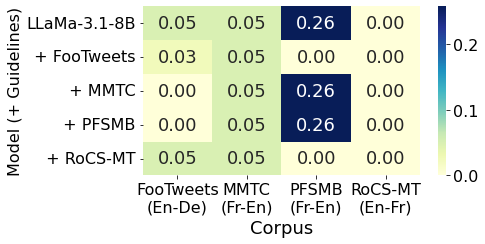

In [142]:
plot_censorship_heatmap(counts, output_dir)

# Robustness of COMET models

In [73]:
import itertools
import pandas as pd

In [52]:
std_sentences = {
    "en": ["He's too funny!"],
    "fr": ["Il est trop drôle !"]
}

ugc_sentences = {
    "en": ["he's too funny!", "his too funny!", "his TOO funny!", "his TOOOO funny!", "his TOOOO funny!!"],
    "fr": ["il est trop drôle !", "il est TROP drôle !", "il est TROOOOP drôle !", "il est TROOOOP drôle !!", "son TROOOOP drôle !!"]
}

In [64]:
sources = []
references = []
outputs = []
for src_lang, tgt_lang in itertools.permutations(["en", "fr"], 2):
    for src in ugc_sentences[src_lang]:
        for ref, output in itertools.permutations(std_sentences[tgt_lang] + ugc_sentences[tgt_lang], 2):
            sources.append(src)
            references.append(ref)
            outputs.append(output)


In [57]:
comet_dir = "/home/lnishimw/scratch/experiments/evaluation-challenges/experiment_049/analysis"

In [66]:
# write the sentences to files
with open(f"{comet_dir}/test.src", "w") as f:
    for line in sources:
        f.write(line + "\n")
with open(f"{comet_dir}/test.ref", "w") as f:
    for line in references:
        f.write(line + "\n")
with open(f"{comet_dir}/test.out", "w") as f:
    for line in outputs:
        f.write(line + "\n")

In [67]:
scores = get_comet_scores(sources, references, outputs)

/scratch/lnishimw/miniconda3/envs/sonar_env/lib/python3.10/site-packages/lightning_fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /scratch/lnishimw/miniconda3/envs/sonar_env/lib/pyth ...
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]
Predicting DataLoader 0: 100%|██████████| 10/10 [00:01<00:00,  7.75it/s]


In [69]:
score_file = f"{comet_dir}/comet_scores.json"
# write_json(score_file, scores)
# read the scores from the file
with open(score_file, "r") as f:
    scores = json.load(f)

In [70]:
comet_scores = scores["sentence_scores"]

In [71]:
for src, ref, output, score in zip(sources, references, outputs, comet_scores):
    print("SRC:", src)
    print("REF:", ref)
    print("SYS:", output)
    print("SCORE:", round(score*100, 2))
    print()

SRC: he's too funny!
REF: Il est trop drôle !
SYS: il est trop drôle !
SCORE: 98.47

SRC: he's too funny!
REF: Il est trop drôle !
SYS: il est TROP drôle !
SCORE: 97.61

SRC: he's too funny!
REF: Il est trop drôle !
SYS: il est TROOOOP drôle !
SCORE: 92.79

SRC: he's too funny!
REF: Il est trop drôle !
SYS: il est TROOOOP drôle !!
SCORE: 90.84

SRC: he's too funny!
REF: Il est trop drôle !
SYS: son TROOOOP drôle !!
SCORE: 66.92

SRC: he's too funny!
REF: il est trop drôle !
SYS: Il est trop drôle !
SCORE: 98.44

SRC: he's too funny!
REF: il est trop drôle !
SYS: il est TROP drôle !
SCORE: 97.75

SRC: he's too funny!
REF: il est trop drôle !
SYS: il est TROOOOP drôle !
SCORE: 94.18

SRC: he's too funny!
REF: il est trop drôle !
SYS: il est TROOOOP drôle !!
SCORE: 92.75

SRC: he's too funny!
REF: il est trop drôle !
SYS: son TROOOOP drôle !!
SCORE: 65.82

SRC: he's too funny!
REF: il est TROP drôle !
SYS: Il est trop drôle !
SCORE: 97.41

SRC: he's too funny!
REF: il est TROP drôle !
SYS

In [74]:
# save to csv file src, ref, output, score
df = pd.DataFrame({
    "src": sources,
    "ref": references,
    "output": outputs,
    "score": comet_scores
})
df.to_csv(f"{comet_dir}/comet_scores.csv", index=False)